<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Beyond the Fundamental: A Spectral Adventure </b></h3>

**Автор**: Ермекова Асель

*P.S.* *На русском перевод емкого и классного названия не получился у меня. Если у вас есть идеи как назвать эту домашку прикольно, пишите в чатике в телеграме ваши предложения русского варианта названия домашки!*

# **Homework: Beyond the Fundamental: A Spectral Adventure**

## **Introduction**

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или А4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## **Submission Instructions**

- Отправьте **Jupyter Notebook** с:
  - Всем кодом
  - Графиками
  - Ответами на вопросы
- Назовите его: `DLS_HW2_Spectrograms_<ваше_имя>.ipynb`

Домашнее задание будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.

# **Load libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# **Task 1: Harmonic and Frequency Spectrum Analysis** [6 score]

### **Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.



### **1.1 Load a WAV file** [0.5 score]
- Download file `Vn-ord-A5-pp-1c-N.wav`
- Use `librosa.load(path, sr=None)` to load the audio. Keep the original sampling rate.
- Print the sampling rate and duration.

In [2]:
!gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O # download violin playing A5: Vn-ord-A5-pp-1c-N.wav

Downloading...
From: https://drive.google.com/uc?id=1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O
To: /content/Vn-ord-A5-pp-1c-N.wav
100% 699k/699k [00:00<00:00, 74.4MB/s]


In [3]:
# Example: Load violin A5
audio_path = '/content/Vn-ord-A5-pp-1c-N.wav'
y, sr = librosa.load(audio_path, sr=None)

print(f"Sampling rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

Sampling rate: 44100 Hz
Duration: 7.93 seconds


### **1.2 Compute the Fourier Transform and plot the magnitude spectrum** [1 score]
- Compute the FFT of the entire audio signal. Use `np.fft.rfft` and `np.fft.rfftfreq`.
- Compute absolute values of the magnitude with `np.abs()` and normalize it.
- Plot the magnitude spectrum (only up to Nyquist frequency).
- Label axes: frequency (Hz) vs magnitude.

> 💡 **Tip**: Normalize magnitude by dividing by `len(signal)`.

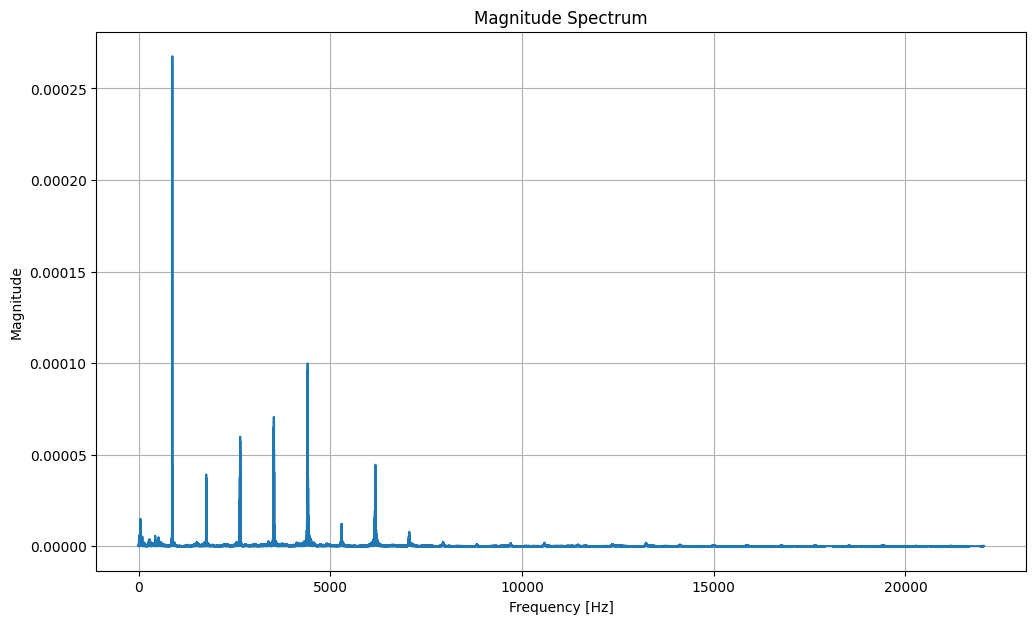

In [4]:
# Compute FFT
fft_result = np.fft.rfft(y)
fft_freq = np.fft.rfftfreq(len(y), 1 / sr)
fft_result_normalize = np.abs(fft_result) / len(y)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(fft_freq, fft_result_normalize)
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

### **1.3 Identify and plot harmonics** [0.5 score]
- Find the **fundamental frequency** (f₀) corresponding to the pitch (e.g., A4 = 440 Hz).
- Calculate harmonics f₀, 2f₀, 3f₀, ..., up to 5000 Hz.
- Plot harmonics as vertical dashed lines and annotate them (e.g., "1st harmonic", "2nd harmonic").

> 📌 **Hint**: You can get theoretical f₀ from `librosa.note_to_hz('A4')`.

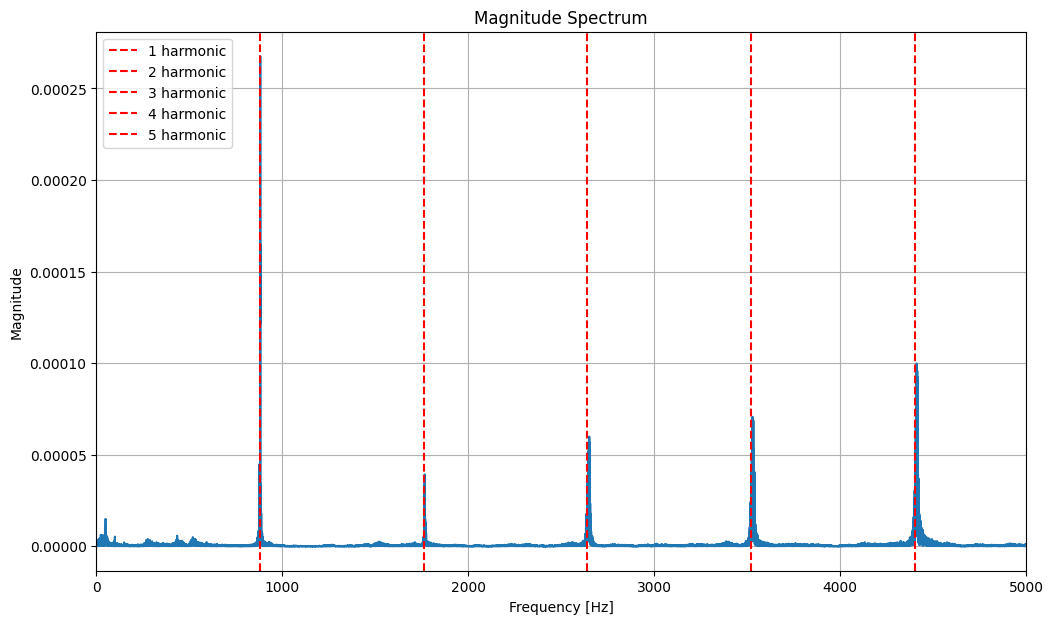

In [5]:
f0 = librosa.note_to_hz('A5')
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n * f0)
    n += 1

# Plot with harmonics marked
plt.figure(figsize=(12, 7))
plt.plot(fft_freq, fft_result_normalize)
for index, harmonic in enumerate(harmonics):
    plt.axvline(harmonic, color='r', linestyle='--', label=f'{index + 1} harmonic')
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.xlim(0, max_freq)
plt.grid()
plt.legend()
plt.show()

### **1.4 Answer: What is the fundamental frequency? What are the amplitudes of the 2nd, 3rd, and 5th harmonics?** [1 score]
- What is the fundamental frequency?
- What are the amplitudes of the 2nd, 3rd, and 5th harmonics?
- Report numerical values (in Hz and amplitude).
- Is the strongest peak always at f₀?

Будем искать максимальную амплитуду около гармоники в заданном диапазоне

In [6]:
# Find peaks near harmonic frequencies
def get_harmonic_amplitude(freq, spectrum, freqs, diff=10):
    mask = (freqs >= freq - diff) & (freqs <= freq + diff)
    return np.max(spectrum[mask])

magnitude = fft_result_normalize
freqs = fft_freq

fundamental_amp = get_harmonic_amplitude(f0, magnitude, freqs)
second_harm_amp = get_harmonic_amplitude(2*f0, magnitude, freqs)
third_harm_amp = get_harmonic_amplitude(3*f0, magnitude, freqs)
fifth_harm_amp = get_harmonic_amplitude(5*f0, magnitude, freqs)

print(f"Fundamental frequency (f0): {f0:.1f} Hz")
print(f"Fundamental amplitude: {fundamental_amp:.4f}")
print(f"2nd harmonic amplitude: {second_harm_amp:.4f}")
print(f"3rd harmonic amplitude: {third_harm_amp:.4f}")
print(f"5th harmonic amplitude: {fifth_harm_amp:.4f}")

Fundamental frequency (f0): 880.0 Hz
Fundamental amplitude: 0.0003
2nd harmonic amplitude: 0.0000
3rd harmonic amplitude: 0.0001
5th harmonic amplitude: 0.0001


- What is the fundamental frequency? Это самая низкая частота в переодическом сигнале, f0 = 880Hz

- Is the strongest peak always at f₀? Нет, не всегда, иногда её может и не быть

### **1.5 Repeat for another instruments playing the same pitch** [1 score]
- Choose a different instruments.
- Repeat steps 1.1–1.3.
- **Compare** the two spectra (Violin and another instrument):
  - Are the harmonic amplitudes similar?
  - Which instrument has more high-frequency harmonics?
  - How does this relate to timbre?

In [7]:
!gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs # Cello: Vc-ord-A5-pp-1c-N.wav
!gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E # Accordion: Acc-ord-A5-pp-N-N.wav
!gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI # Flute: Fl-ord-A5-pp-N-N.wav

Downloading...
From: https://drive.google.com/uc?id=19RVoksj40dds4lfSiha17HuTLYCFvwCs
To: /content/Vc-ord-A5-pp-1c-N.wav
100% 651k/651k [00:00<00:00, 83.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E
To: /content/Acc-ord-A5-pp-N-N.wav
100% 600k/600k [00:00<00:00, 98.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI
To: /content/Fl-ord-A5-pp-N-N.wav
100% 535k/535k [00:00<00:00, 109MB/s]


In [8]:
database = {'Accordion': 'Acc-ord-A5-pp-N-N.wav',
            'Cello': 'Vc-ord-A5-pp-1c-N.wav',
            'Flute': 'Fl-ord-A5-pp-N-N.wav',
            'Violin': 'Vn-ord-A5-pp-1c-N.wav'}

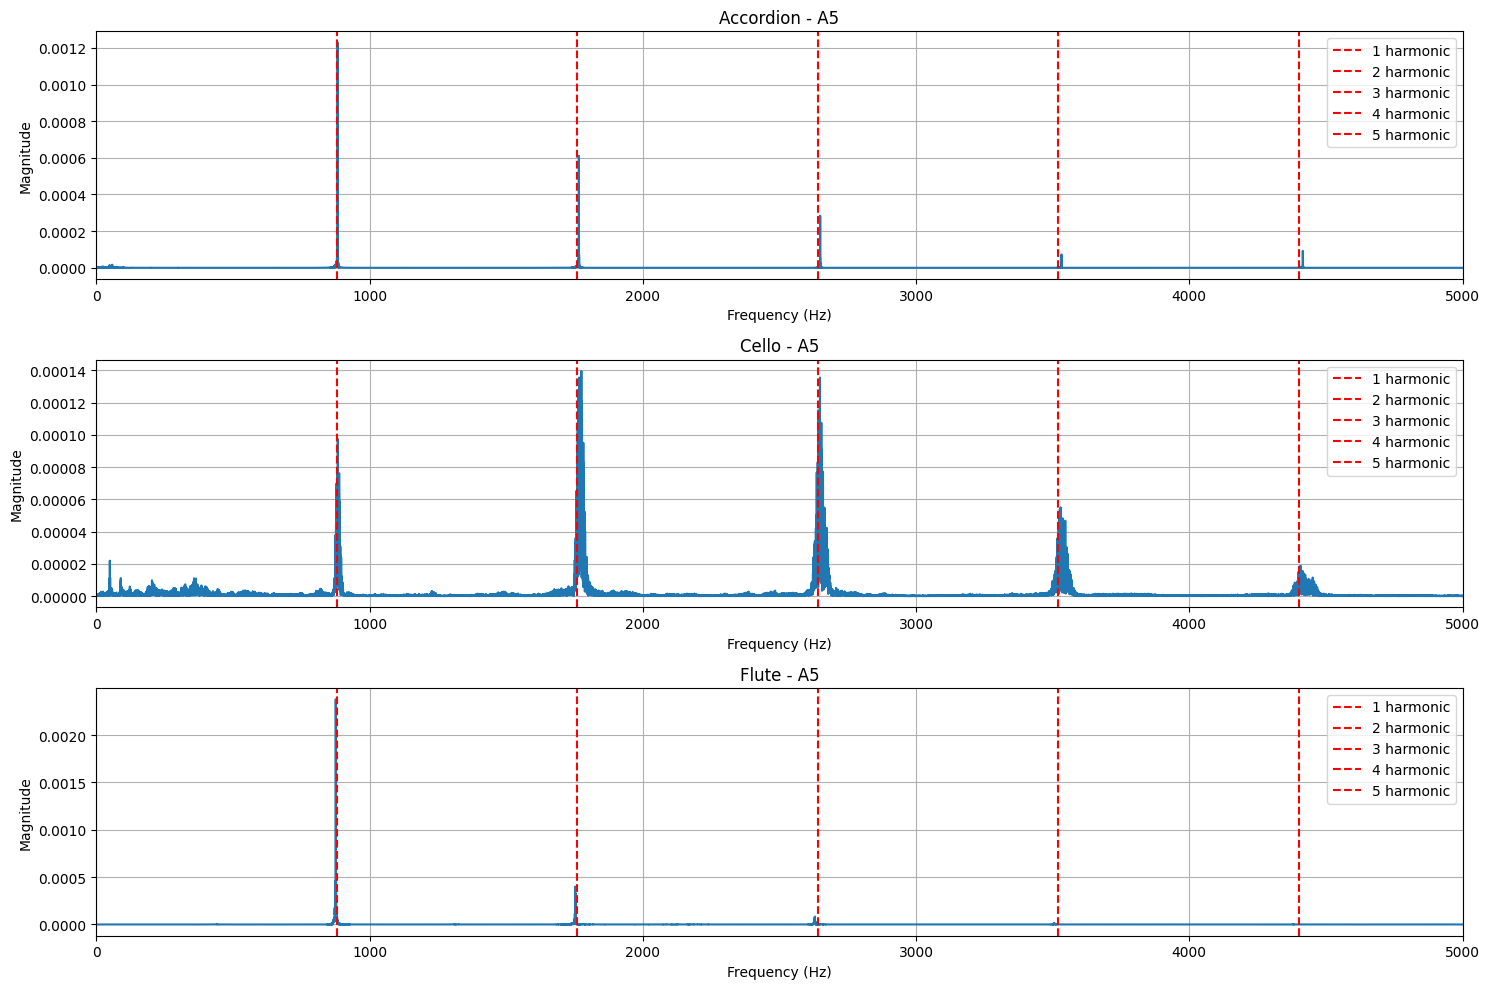

In [9]:
instruments_to_compare = ['Accordion', 'Cello', 'Flute']
plt.figure(figsize=(15, 10))

for i, inst in enumerate(instruments_to_compare):

    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(database[inst], sr=None)

    f0 = librosa.note_to_hz('A5')
    max_freq = 5000
    harmonics = []
    n = 1
    while n * f0 <= max_freq:
        harmonics.append(n * f0)
        n += 1

    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1 / sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    plt.subplot(3, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    for index, harmonic in enumerate(harmonics):
        plt.axvline(harmonic, color='r', linestyle='--', label=f'{index + 1} harmonic')
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - A5')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

- **Compare** the two spectra (Violin and Accordion):
  - Are the harmonic amplitudes similar?
  - Нет, амплитуды не схожи, у аккордиона примерно в 2 раза меньше
  - Which instrument has more high-frequency harmonics?
  - У скрипки и аккордиона поровну высокочастотных гармоник в диапазоне до 5кГц
  - How does this relate to timbre?
  - Много гармнокик - звук резкий, прозительный

- **Compare** the two spectra (Violin and Cello):
  - Are the harmonic amplitudes similar?
  - Нет, амплитуды не схожи, у виолончели примерно в 1,5 раза меньше, но зато у неё амплитуды больше похожи на f0
  - Which instrument has more high-frequency harmonics?
  - У скрипки и виолончели поровну высокочастотных гармоник в диапазоне до 5кГц
  - How does this relate to timbre?
  - Много гармнокик - звук резкий, прозительный

- **Compare** the two spectra (Violin and Flute):
  - Are the harmonic amplitudes similar?
  - Амплитуды схожи, но у флейты они достаточно резко падают в 0
  - Which instrument has more high-frequency harmonics?
  - У скрипки больше высокочастотных гармоник в диапазоне до 5кГц, у флейты всего 2
  - How does this relate to timbre?
  - Мало гармоник - звук более мягкий, чистый

### **1.6 Count significant harmonics** [1 score]
- Define a "significant harmonic" as one with amplitude > 10% of the max amplitude.
- For **Flute** and **Violin** (same pitch), count how many significant harmonics each has.
- Which instrument is "brighter"? Why?

In [10]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1):
    harmonics = []
    n = 1
    mask = freqs <= max_freq
    max_amplitude = np.max(magnitude[mask])

    while n * f0 <= max_freq:
        if get_harmonic_amplitude(n * f0, magnitude, freqs) >= max_amplitude * threshold_ratio:
            harmonics.append(n * f0)
        n += 1

    return len(harmonics), harmonics

# Compare Flute and violin
for inst in ['Flute', 'Violin']:
    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1 / sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f"{inst.capitalize()}: {count} significant harmonics")

Flute: 2 significant harmonics
Violin: 5 significant harmonics


Скрипка звучит ярче, так как у неё больше значимых гармоник

### **1.7. Simple Instrument Classification** [2 score]
- Select 3 instruments, each with 10 examples of the **same pitch** (e.g., A4).
- **Approach A**: Use raw audio waveforms (flattened) as features → train a Random Forest.
- **Approach B**: Use magnitude spectrum (first 1024 bins) as features → train same model.
- Compare accuracy on a test set.
- **Question**: Why does Approach B perform better?

> 🛠️ Use `sklearn.tree.RandomForestClassifier` and `train_test_split`.

First, download dataset.

In [11]:
!gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO # download dataset

Retrieving folder contents
Retrieving folder 1iRMqnkH7_GFqdt4EQ-XNIvzrGpWEY7BJ Strings
Retrieving folder 1AYkFHBz5tmYeC_TXouqyrXHobvwlpmAg Violin
Retrieving folder 1MczsLg3MRdzt5-xJ6nvqxRAaEjUOCZ27 ordinario
Processing file 14EjlXc_tdIJYbyMysUiC4hLRYfjV3HAv Vn-ord-A5-ff-1c-N.wav
Processing file 1JVag7kvYhGLW5ZVLJ-mxDXZ-F1wPLA02 Vn-ord-A5-ff-2c-N.wav
Processing file 1vQl-LIBK1JakJoDdR7sv-jdidz_COToj Vn-ord-A5-ff-3c-N.wav
Processing file 1z85hpjJPvFXp1V5cD3pD88-8aD0Zn1a1 Vn-ord-A5-mf-1c-N.wav
Processing file 1jptv0jF2rwILfPXwo8DdtWK533p4OK13 Vn-ord-A5-mf-2c-N.wav
Processing file 1jRAo5qm2zIsqf0sGzowAzb4emktEopWz Vn-ord-A5-mf-3c-N.wav
Processing file 1kbocn0_6etfg_LLBX4SAESNwBAqxOyWi Vn-ord-A5-pp-1c-N.wav
Processing file 1p5Xs5rXQX6e_wAtLXOixcB7C6hB9aEgI Vn-ord-A5-pp-2c-N.wav
Processing file 1E2xvckcJZSu68_yyJM_xl8aWsudNRZ5n Vn-ord-A5-pp-3c-N.wav
Retrieving folder 1bgPVnul9gXyQ1GK2YJDCY3JzKkcVlyRi Violoncello
Retrieving folder 1CjCmGKunsLKLLxfB8mbvZP7--YepiIH0 ordinario
Processing file 1q

In [12]:
df = pd.read_csv("/content/TinySOL_short/TinySOL_short.csv")

In [13]:
df

,Path,Fold,Family,Instrument (abbr.),Instrument (in full),Technique (abbr.),Technique (in full),Pitch,Pitch ID,Dynamics,Dynamics ID,Instance ID,String ID (if applicable),Needed digital retuning
0,TinySOL_short/Strings/Violoncello/ordinario/Vc...,0,Strings,Vc,Cello,ord,ordinario,A5,81,pp,0,0,1.0,False
1,TinySOL_short/Strings/Violoncello/ordinario/Vc...,3,Strings,Vc,Cello,ord,ordinario,A5,81,mf,2,0,1.0,False
2,TinySOL_short/Strings/Violoncello/ordinario/Vc...,4,Strings,Vc,Cello,ord,ordinario,A5,81,ff,4,0,1.0,True
3,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,4,Strings,Vn,Violin,ord,ordinario,A5,81,pp,0,0,1.0,False
4,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,4,Strings,Vn,Violin,ord,ordinario,A5,81,pp,0,1,2.0,False
5,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,2,Strings,Vn,Violin,ord,ordinario,A5,81,pp,0,2,3.0,False
6,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,1,Strings,Vn,Violin,ord,ordinario,A5,81,mf,2,0,1.0,False
7,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,3,Strings,Vn,Violin,ord,ordinario,A5,81,mf,2,1,2.0,False
8,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,1,Strings,Vn,Violin,ord,ordinario,A5,81,mf,2,2,3.0,False
9,TinySOL_short/Strings/Violin/ordinario/Vn-ord-...,3,Strings,Vn,Violin,ord,ordinario,A5,81,ff,4,0,1.0,False


Тут я не понял, что значит 10 примеров каждого инструмента, хотя в датасете их меньше, поэтому сделал трансформации (ускорение/замедление) для случайных примеров, чтобы добить недостающие примеры

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from random import uniform

# Prepare data for 3 instruments, same pitch (A5)
instruments_class = ['Violin', 'Flute', 'Cello']
X_wave = []
X_spec = []
y_labels = []
counter = dict()

pitch = 'A5'

for path, instrument in df[(df['Pitch'] == pitch) & (df['Instrument (in full)'].isin(instruments_class))][['Path', 'Instrument (in full)']].itertuples(index=False):
    y_labels.append(instruments_class.index(instrument))
    counter[instrument] = counter.get(instrument, 0) + 1
    wav, sr = librosa.load(path)
    X_wave.append(wav[:100000])

    wav_inst = np.fft.rfft(wav)
    freqs_inst = np.fft.rfftfreq(len(wav_inst), 1 / sr)
    magnitude_inst = np.abs(wav_inst) / len(wav)
    X_spec.append(magnitude_inst[:1024])

for key, value in counter.items():
    miss = 10 - value
    for _ in range(miss):
        path = df[(df['Pitch'] == pitch) & (df['Instrument (in full)'] == key)][['Path', 'Instrument (in full)']].sample(1)[['Path']].values[0][0]
        y_labels.append(instruments_class.index(key))

        wav, sr = librosa.load(path)
        rate = uniform(0.8, 1.2)
        wav = librosa.effects.time_stretch(wav, rate=rate)

        X_wave.append(wav[:100000])

        wav_inst = np.fft.rfft(wav)
        freqs_inst = np.fft.rfftfreq(len(wav_inst), 1 / sr)
        magnitude_inst = np.abs(wav_inst) / len(wav)
        X_spec.append(magnitude_inst[:1024])



# Split data
X_train_wave, X_test_wave, y_train_wave, y_test_wave = train_test_split(X_wave, y_labels, random_state=42, train_size=0.75, stratify=y_labels)
X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(X_spec, y_labels, random_state=42, train_size=0.75, stratify=y_labels)

# Train classifiers
clf_wave = RandomForestClassifier()
clf_wave.fit(pd.DataFrame(X_train_wave).values, y_train_wave)
clf_spec = RandomForestClassifier()
clf_spec.fit(pd.DataFrame(X_train_spec).values, y_train_spec)


# Evaluate
acc_wave = accuracy_score(clf_wave.predict(pd.DataFrame(X_test_wave).values), y_test_wave)
acc_spec = accuracy_score(clf_spec.predict(pd.DataFrame(X_test_spec).values), y_test_spec)

print(f"Accuracy with raw waveforms: {acc_wave:.3f}")
print(f"Accuracy with spectra: {acc_spec:.3f}")

Accuracy with raw waveforms: 0.500
Accuracy with spectra: 0.750


**Answer**: Подход Б показал лучший результат, так как на спектр не оказывает влияение ускорение/замедление и сдвиг по времени, в отличии от сырых wav, которые чувствительны к этим изменениям

# **Task 2: Windowing in STFT – Why Not Rectangular?** [10 score]

### **Goal**: Understand spectral leakage and why smooth windows (e.g., Hann) are preferred.

### **2.1 Load a pure sine wave** [0.5 score]
- Generate a 440 Hz sine wave, 1 second long, at 22050 Hz sampling rate.
- Plot the waveform.

$$y = \sin(2 \pi ft)$$

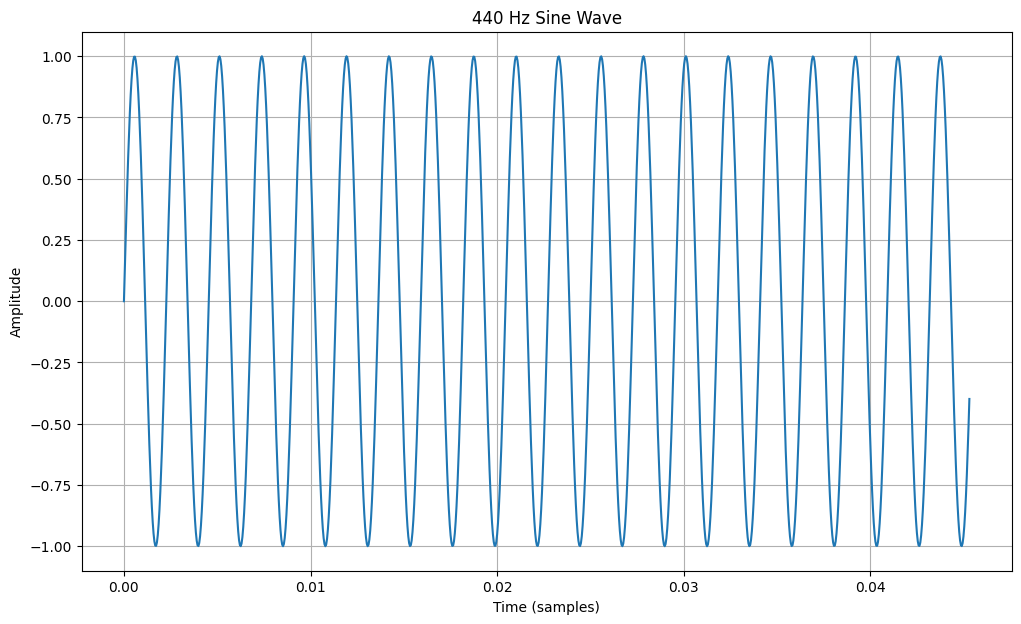

In [17]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2 * np.pi * f0 * t)
plt.figure(figsize=(12, 7))
plt.plot(t[:1000], sine_wave[:1000])
plt.title('440 Hz Sine Wave')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Plot waveform and Show first 1000 samples

### **2.2 Compute STFT with rectangular window** [1 score]
- Use `scipy.signal.stft` with `window='boxcar'` (rectangular), `nperseg=1024`, `noverlap=512`.
- Plot the spectrogram (use `plt.pcolormesh` with dB scale).

> 💡 Convert to dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

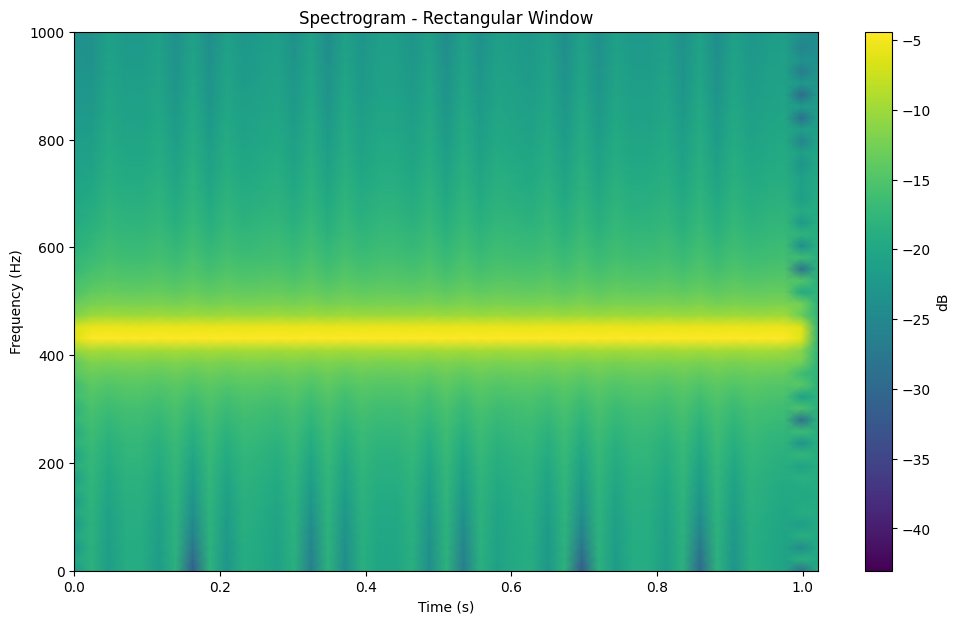

In [18]:
from scipy.signal import stft

# Compute STFT with rectangular window
f_boxcar, t_boxcar, Zxx_boxcar = stft(sine_wave, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_boxcar, f_boxcar, 10 * np.log10(np.abs(Zxx_boxcar) + 1e-10), shading='gouraud')
plt.title('Spectrogram - Rectangular Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(0, 1000)
plt.show()

### **2.3 Compute STFT with Hann window** [1 score]
- Repeat with `window='hann'`.
- Plot the spectrogram.

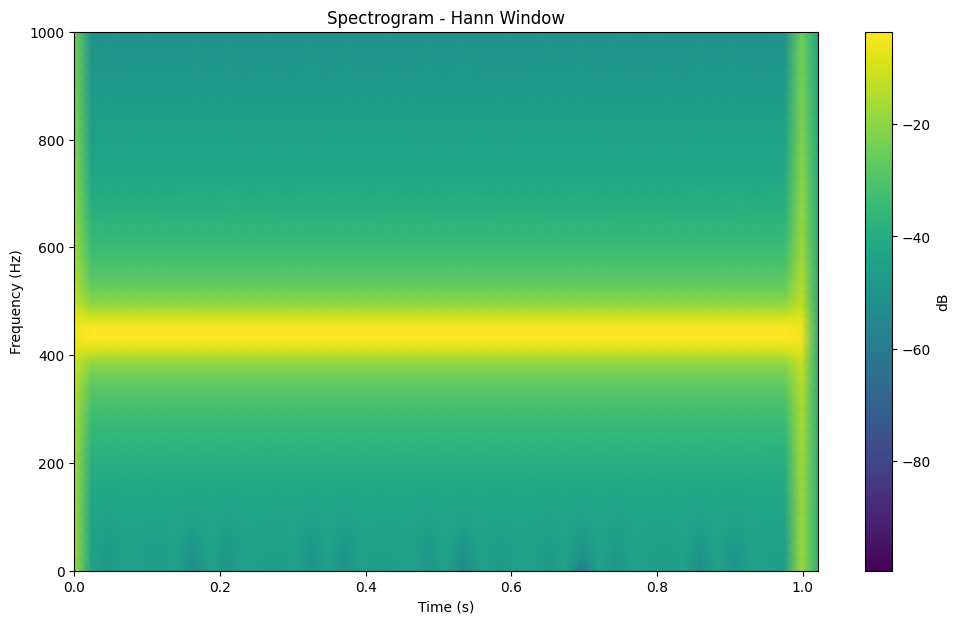

In [19]:
# Compute STFT with hann window
f_hann, t_hann, Zxx_hann = stft(sine_wave, fs=sr, window='hann', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_hann, f_hann, 10 * np.log10(np.abs(Zxx_hann) + 1e-10), shading='gouraud')
plt.title('Spectrogram - Hann Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(0, 1000)
plt.show()

### **2.4 Compare the two spectrograms** [1.5 score]
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? [0.5 score]
- **Question**: Is the main lobe wider or narrower with Hann? [0.5 score]
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? [0.5 score]

Answers to questions:
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? Энергия наблюдается на частоте около 400 Hz, а также в начале временного ряда (0s) и конце временного ряда (1s) на всех частотах.
- **Question**: Is the main lobe wider or narrower with Hann? Визуально главный лепесток более широкий при окне Ханна
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? Визуально окно Ханна обеспечивает более чистый и сфокусированный сигнал на частоте 440 Гц, то есть переход от 440 Гц к другим частотам более плавный и вся энергия остаётся около 440 Гц
     

### **2.5 Try a signal with two close frequencies** [2 score]
- Generate two sine waves: 440 Hz and 460 Hz.
- Repeat 2.2 and 2.3.
- **Question**: Can you distinguish the two tones with rectangular window? With Hann?


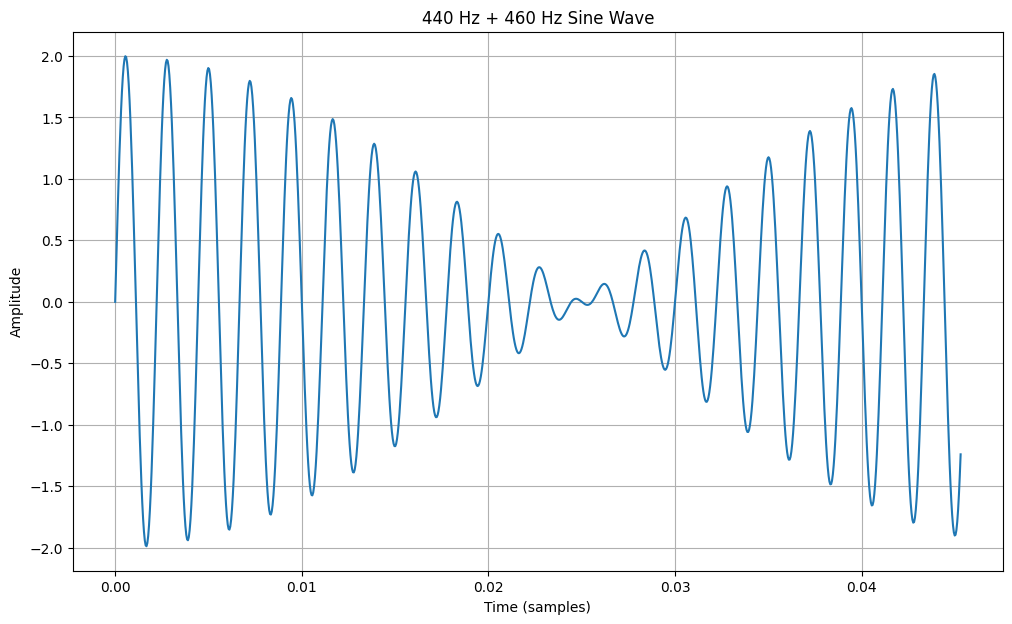

In [20]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0_2 = 460
sine_wave_2 = np.sin(2 * np.pi * f0 * t) + np.sin(2 * np.pi * f0_2 * t)
plt.figure(figsize=(12, 7))
plt.plot(t[:1000], sine_wave_2[:1000])
plt.title('440 Hz + 460 Hz Sine Wave')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

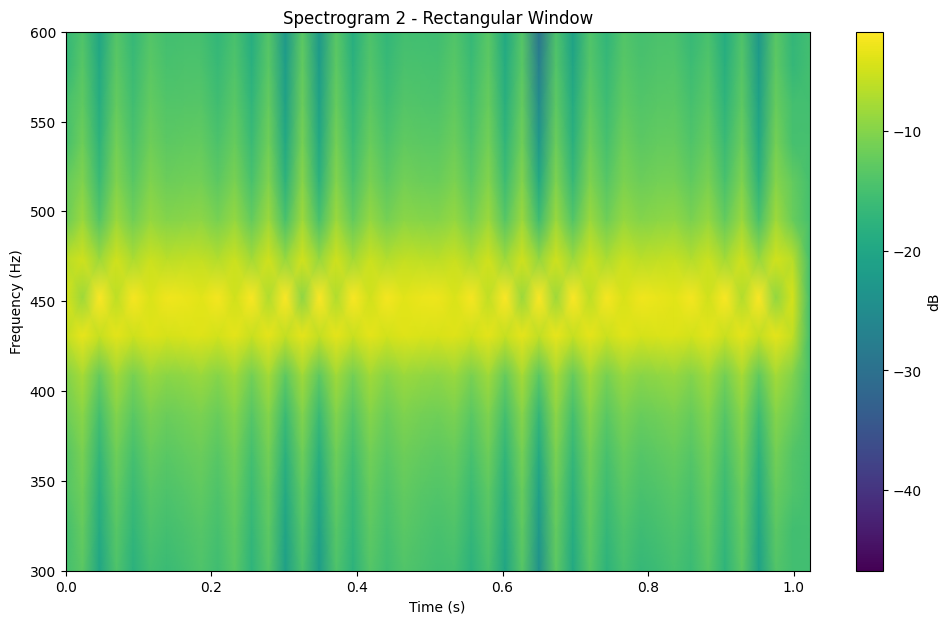

In [21]:
f_boxcar_2, t_boxcar_2, Zxx_boxcar_2 = stft(sine_wave_2, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_boxcar_2, f_boxcar_2, 10 * np.log10(np.abs(Zxx_boxcar_2) + 1e-10), shading='gouraud')
plt.title('Spectrogram 2 - Rectangular Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(300, 600)
plt.show()

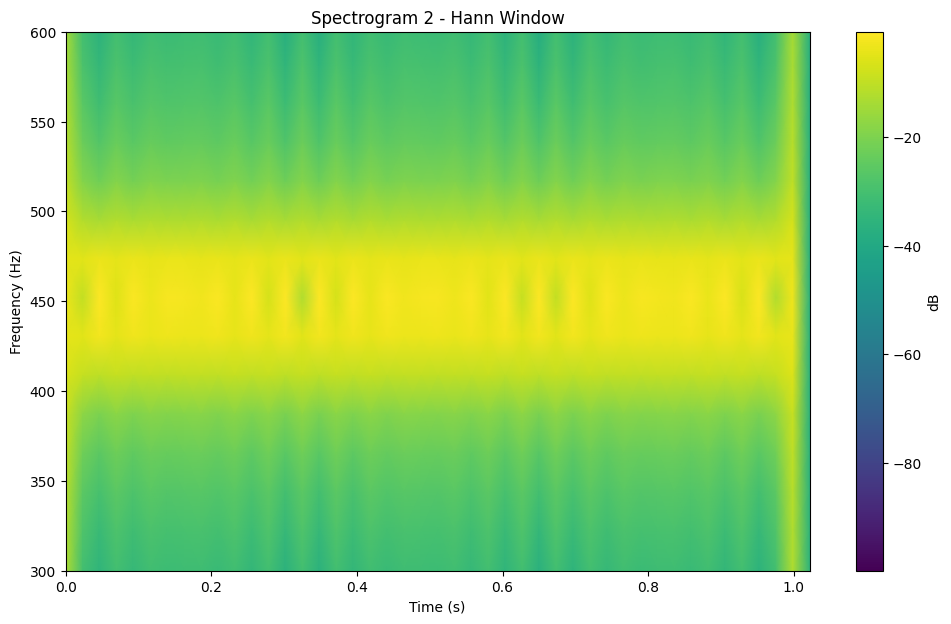

In [22]:
# Compute STFT with hann window
f_hann_2, t_hann_2, Zxx_hann_2 = stft(sine_wave_2, fs=sr, window='hann', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_hann_2, f_hann_2, 10 * np.log10(np.abs(Zxx_hann_2) + 1e-10), shading='gouraud')
plt.title('Spectrogram 2 - Hann Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(300, 600)
plt.show()

**Answer**: Практически невозможно различить два тона как при использовании прямоугольного, так и при использовании окна Ханна

### **2.6 Analyze a real instrument note** [1 score]
- Load a flute note (A5).
- Compute spectrograms with rectangular and Hann windows.
- **Question**: Does rectangular window create "smearing" or artificial frequencies? [0.5 score]
- **Question**: Which spectrogram better reflects the true harmonic structure? [0.5 score]

In [23]:
# Load flute note A5
row = df[(df['Instrument (in full)'] == "Flute") & (df['Pitch'] == 'A5')].iloc[0]
y_inst, sr_inst = librosa.load(row['Path'], sr=None)

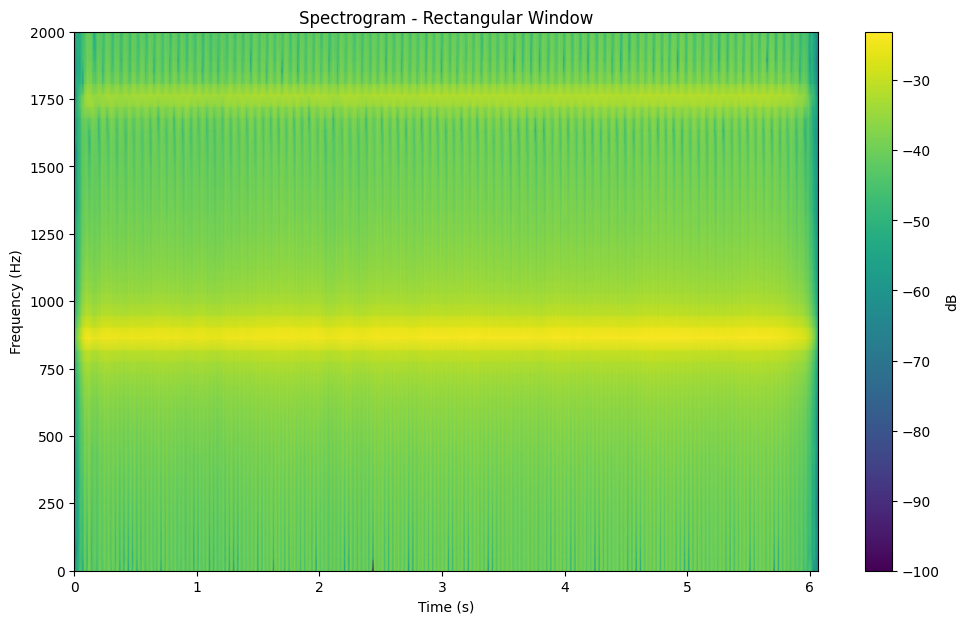

In [24]:
f_flure_rect, t_flure_rect, Zxx_flure_rect = stft(y_inst, fs=sr_inst, window='boxcar', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_flure_rect, f_flure_rect, 10 * np.log10(np.abs(Zxx_flure_rect) + 1e-10), shading='gouraud')
plt.title('Spectrogram - Rectangular Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(0, 2000)
plt.show()

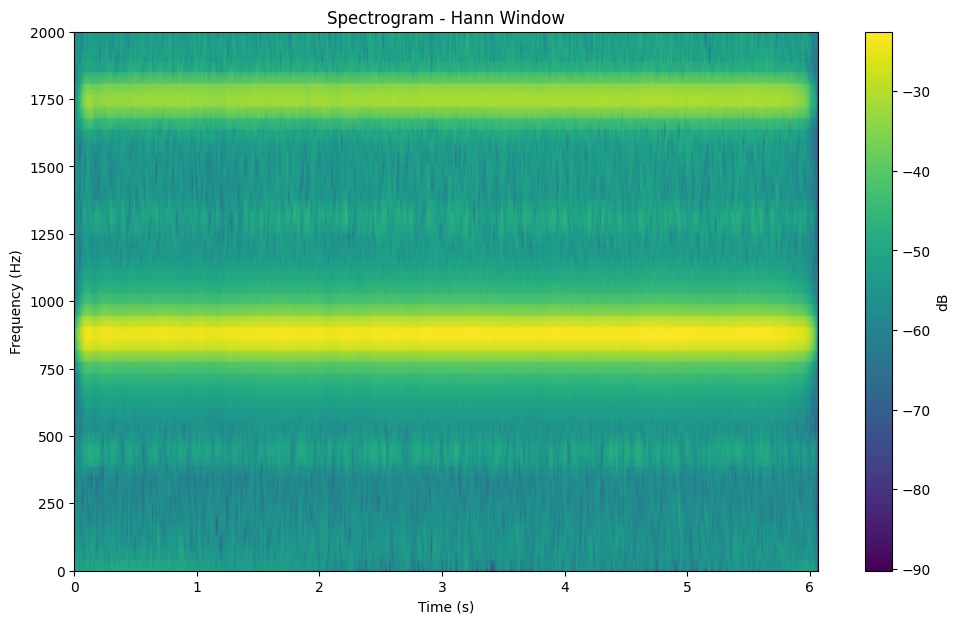

In [25]:
f_flure_hann, t_flure_hann, Zxx_flure_hann = stft(y_inst, fs=sr_inst, window='hann', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 7))
graph = plt.pcolormesh(t_flure_hann, f_flure_hann, 10 * np.log10(np.abs(Zxx_flure_hann) + 1e-10), shading='gouraud')
plt.title('Spectrogram - Hann Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(graph).set_label('dB')
plt.ylim(0, 2000)
plt.show()

- **Question**: Does rectangular window create "smearing" or artificial frequencies? Да, квадратное окно вызывает появление искусственных частот, это можно заметить на крафике. Значение близкое к максимальной энергии можно увидеть на абсолютно разных частотах на протяжении всего временного ряда
- **Question**: Which spectrogram better reflects the true harmonic structure? Спектрограмма с окном Ханна явно лучше отражает истинную структуру, так как по графикам видно, что максимальная энергия достигается около гармоник, а с квадратным окном может быть размыта по всем частотам

### **2.7 Conclusion** [3 score]
- Write 3–4 sentences explaining:
  - What is **spectral leakage**?
  - Why does rectangular window cause it?
  - Why is a smooth (bell-shaped) window better for audio analysis?

**Answer**:
- What is **spectral leakage**?
- Это такая ситуация, когда при прохождении прямоугольной оконной функции, энергия "растекается" по всему спектру на краях этого окна. Это вызывает ложные частоты, которые могут давать ложную оценку сигналу.
- Why does rectangular window cause it?
- Прямоугольное окно обрезает сигнал по краям сигнала. И если внутри этого окна нет целого числа периодов (а это как-будто практически всегда так), тогда возникает разрыв, который необходимо преобразовать в ступеньку, чтобы корректно начать обрабатывать сигнал.
- Why is a smooth (bell-shaped) window better for audio analysis?
- Сглаживающее окно, как окно Ханна, сглаживает ампитуду на краях окна. Поэтому при переходе к следующему окну нет такого резкого перепада или скачка, как при прямоугольном окне.

# **Task 3: Implement Your Own Mel-Spectrogram Transform** [5 score]

### **Goal**: Understand how Mel-scale warping works by implementing it manually.

### **3.1 Load an audio file** [0.5 score]
- Pick any `.wav` from the dataset.
- Load with `librosa.load(..., sr=22050)`.

In [26]:
# Load audio
sample = df.iloc[0]
y, sr = librosa.load(sample['Path'], sr=22050)

### **3.2 Compute STFT** [0.5 score]
- Use `librosa.stft` with `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Compute power spectrogram: `S = np.abs(stft_result) ** 2`.

In [27]:
# Compute STFT
stft_result = librosa.stft(y, n_fft=2048, hop_length=512, window='hann')
S = np.abs(stft_result) ** 2

### **3.3 Create Mel filterbank manually** [2 score]
- Number of Mel bands: `n_mels = 128`.
- Frequency range: 0 to `sr/2`.
- Steps:
  1. Convert Hz to Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Create `n_mels + 2` equally spaced points in Mel scale.
  3. Convert back to Hz.
  4. Build triangular filters (each filter overlaps with neighbors).
- Output: a matrix `mel_basis` of shape `(n_mels, n_fft//2 + 1)`.

> 📚 Reference: [Librosa mel filterbank docs](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

In [28]:
def hz_to_mel(frequencies):
    """Convert Hz to Mel scale"""
    return 2595 * np.log10(1 + frequencies / 700)

def mel_to_hz(mels):
    """Convert Mel to Hz scale"""
    return 700 * (10 ** (mels / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """Create Mel filterbank manually"""
    if fmax is None:
        fmax = sr / 2

    # Frequency bins
    n_freqs = n_fft // 2 + 1
    linear_freqs = np.linspace(0, fmax, n_freqs)

    # Mel points
    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    # Create filterbank
    filterbank = np.zeros((n_mels, n_freqs))

    for m in range(n_mels):
        # Triangle vertices
        left = hz_points[m]
        center = hz_points[m + 1]
        right = hz_points[m + 2]

        up = (linear_freqs - left) / (center - left)
        down = (right - linear_freqs) / (right - center)

        filterbank[m] = np.maximum(0, np.minimum(up, down))

    return filterbank


# Create filterbank
n_fft = 2048
mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels=128)

### **3.4 Apply filterbank to power spectrogram** [0.5 score]
- Compute: `mel_spec_manual = np.dot(mel_basis, S)`

In [29]:
# Apply manual filterbank
mel_spec_manual = np.dot(mel_basis_manual, S)

### **3.5 Compute Mel-spectrogram using librosa** [0.5 score]
- Use `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

Добавим параметры, чтобы Mel-спектрограммы были равны

In [30]:
# Librosa version
mel_spec_librosa = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128, htk=True, norm=None)

### **3.6 Compare and validate** [1 score]
- Use `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- If not close, debug your filterbank.
- Plot both Mel-spectrograms side by side (in dB scale).
- **Question**: Are they visually identical?

Manual and librosa implementations match: True


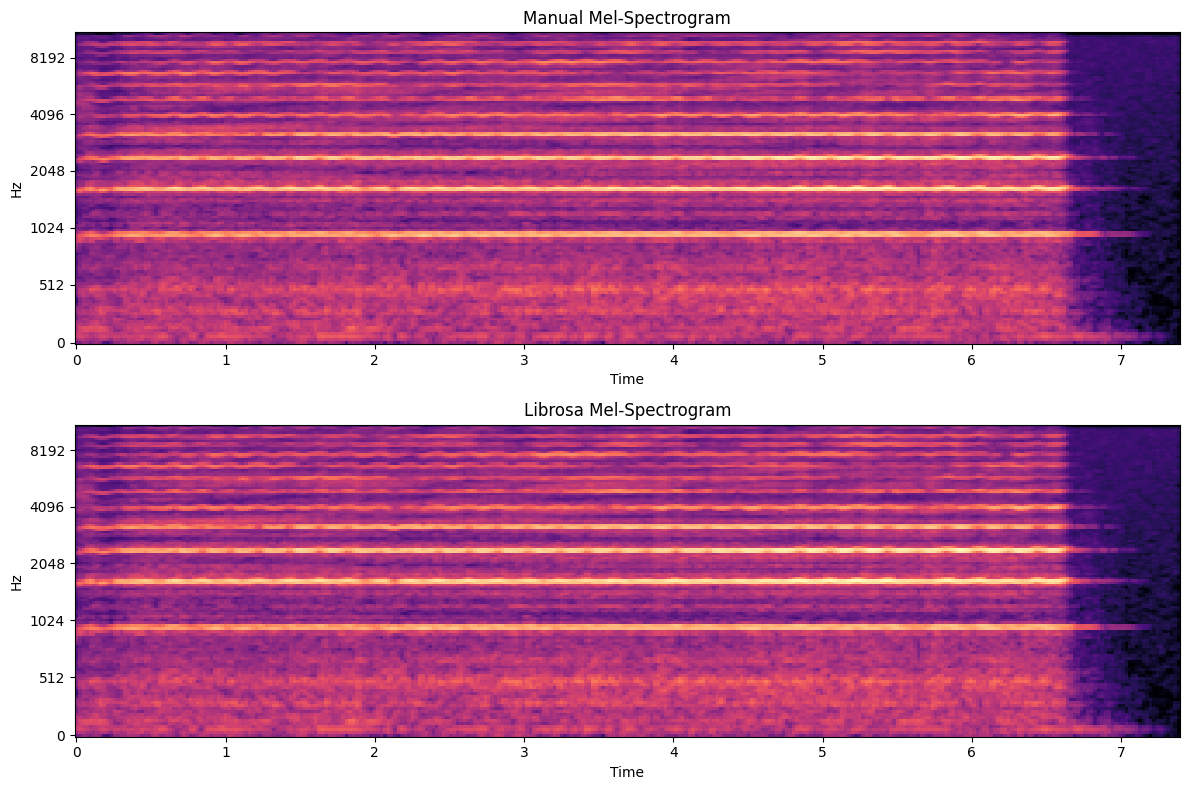

In [31]:
# Compare
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)
print(f"Manual and librosa implementations match: {are_close}")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')

librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Librosa Mel-Spectrogram')

plt.tight_layout()
plt.show()

Графики выглядят визуально идентично

### **3.7 Bonus: Try with torchaudio**
- Repeat using `torchaudio.transforms.MelSpectrogram`.
- Compare with your implementation.

In [32]:
# !pip install torch torchaudio

In [33]:
import torchaudio
import torch
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, n_fft=n_fft, hop_length=512, n_mels=128
)
mel_spec_torch = mel_transform(torch.tensor(y)).numpy()

# Note: torchaudio uses different scaling, so direct comparison needs care


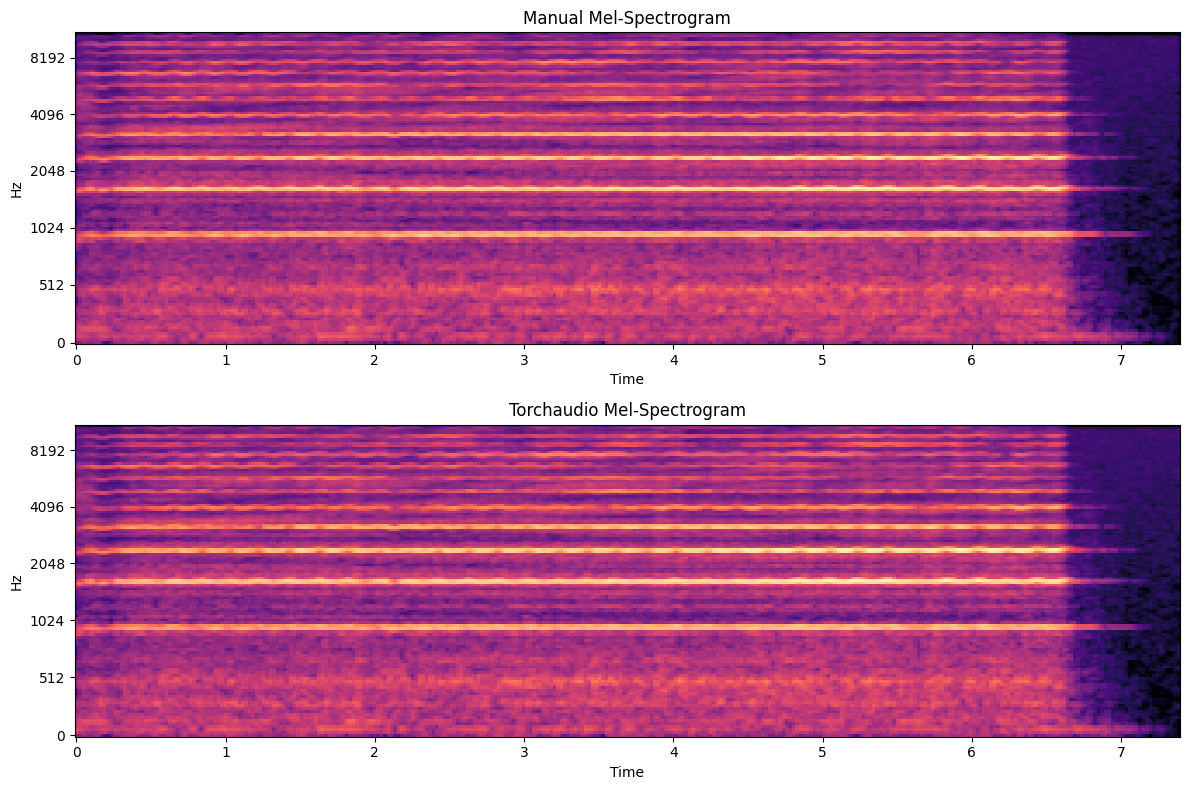

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')

librosa.display.specshow(
    librosa.power_to_db(mel_spec_torch, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Torchaudio Mel-Spectrogram')

plt.tight_layout()
plt.show()